# Clustering configs

## functions

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import matplotlib.patches as mpatches
import re

def get_cluster_files (cluster, df_path):
    df_assignments = pd.read_csv(df_path)
    df_assignments_filtered =  df_assignments[ df_assignments["label"].str.contains(str(cluster))]
    cluster_files = df_assignments_filtered ["file"].values
    cluster_genres = [genres for genres in df_assignments_filtered ["label"].unique() if "(" in genres ][0]
    return cluster_files, cluster_genres


def mean_scores(scores_list):
    return pd.DataFrame(scores_list).mean().to_dict()
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)
def std_scores(scores_list):
  
    return pd.DataFrame(scores_list).std().to_dict()

def extract_mean_std(scores, extract_std = False, trial= None, decimals = 3, name = None):
    name = "" if name is None else f"{name}"
    suffix = f"{name}_baseline" if trial is None else f"{name}_model_{trial}"
    mean_dict = mean_scores(scores)
    if not extract_std:
        res = pd.DataFrame.from_dict(
            mean_dict,
            orient="index",
            columns=[suffix]
        ).T
    else:
        std_dict = std_scores(scores)

        fmt = f"{{:.{decimals}f}}"
        combined = {
            k: f"{fmt.format(mean_dict[k])} +- {fmt.format(std_dict[k])}"
            for k in mean_dict.keys()
        }

        res = pd.DataFrame.from_dict(
            combined,
            orient="index",
            columns=[suffix]
        ).T
    return res

def remove_cemgil (df):
    wt_cemgil= [col for col in df.columns.values if "Cemgil" not in col]
    df= df[wt_cemgil]
    return df

def get_per_cluster_results(trials, seeds,json_path, cluster, name_full, cluster_config = None, 
                 df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv", trial_names = None, extrat_std = False, decimals = 3):
    df_list = []
    for trial in trials:
        name = trial_names.get(trial, "") if trial_names else ""
        scores, genres = get_restults_per_cluster(
                    json_path, cluster=cluster, seeds=seeds, cluster_config=cluster_config,
                    df_path=df_path, full=False, filter_files=True, name = f"cluster_{cluster}_trial_{trial}{name}"
                
                )
        if len(seeds) >1:
            res = extract_mean_std(scores, trial = trial, extract_std=extrat_std, decimals = decimals)
         
        else:
            res = pd.DataFrame.from_dict(scores[0]  , orient="index", columns=[f"trial_{trial}"])
            res = pd.DataFrame(res).T         
        
        df_list.append(res)

    scores_base = get_restults_per_cluster(
                json_path, cluster=cluster, seeds=seeds, cluster_config=cluster_config,
                df_path=df_path, full=True, filter_files=True, name = name_full
            )
    
    
    if len(seeds) >1:
        res_base = extract_mean_std(scores_base, trial = None, extract_std=extrat_std, decimals = decimals)
    else:
        res_base = pd.DataFrame.from_dict(scores_base[0]  , orient="index", columns=[f"baseline"])
        res_base = pd.DataFrame(res_base).T
    df_list.append(res_base)
    df_total = pd.concat(df_list, axis=0)
    df_total = remove_cemgil(df_total)
    return df_total 


def get_baseliine_diff(df_total, num_trials):
    df_baseline = df_total.loc["baseline"]
    diff_vs_baseline = df_total[:num_trials].subtract(df_total.loc["baseline"])
    diff_vs_baseline
    diff_vs_baseline = pd.concat([diff_vs_baseline, df_baseline.to_frame().T], axis=0)
    return diff_vs_baseline


def get_latex_row(df, remove_cemgil = True):
    if remove_cemgil:
        wt_cemgil= [col for col in df.columns.values if "Cemgil" not in col]
        df= df[wt_cemgil]
    rows = [
    " & ".join(f"{x:.3f}" if isinstance(x, (int, float)) else str(x) for x in row)
    for row in df.values
]
    return rows

def _extract_mean(value):
    s = str(value)
    s = s.replace("$", "").strip()
    s = s.replace(r"\pm", "+-").replace("±", "+-")
    if "+-" in s:
        mean_part = s.split("+-")[0].strip()
    else:
        mean_part = s.split()[0].strip()
    try:
        return float(mean_part)
    except ValueError:
        return np.nan

In [5]:
import re
import numpy as np

_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _extract_mean(value):
    """
    Robustly extract the first numeric value from a cell like:
    '96.643 +- 0.114', '96.643 ± 0.114', '96.643 \\pm 0.114',
    '\\mathbf{96.64} \\pm 0.11', 'clusters4_layer12 92.81 ± 0.11'
    """
    if value is None:
        return np.nan
    s = str(value).replace("$", "").strip()

    m = _num_re.search(s)
    return float(m.group(0)) if m else np.nan


In [ ]:
def df_to_latex_rows(
    df,
    rename_idx=None,
    bold_index=True,
    pm=False,
    bold_difference=False,
    bold_baseline_if_best=False,
    bold_max_per_col=False,         
):
    rows = []
    baseline_idx = None
    for idx in df.index:
        if "baseline" in str(idx).lower():
            baseline_idx = idx
            break

    baseline_means = {}
    if baseline_idx is not None:
        for col in df.columns:
            baseline_means[col] = _extract_mean(df.loc[baseline_idx, col])

    baseline_best_cols = set()
    if bold_baseline_if_best and baseline_idx is not None:
        for col in df.columns:
            others = [
                _extract_mean(df.loc[i, col])
                for i in df.index
                if i != baseline_idx
            ]
            if len(others) > 0:
                if baseline_means[col] >= np.nanmax(others):
                    baseline_best_cols.add(col)

    max_cells = set()
    if bold_max_per_col:
        for col in df.columns:
            means = {i: _extract_mean(df.loc[i, col]) for i in df.index}
            print(col)
            print(means)
            max_val = np.nanmax(list(means.values()))
            for i, mv in means.items():
                if not np.isnan(mv) and mv == max_val:
                    max_cells.add((i, col))

    for i, (idx, row) in enumerate(df.iterrows()):
        label = str(rename_idx[i]) if rename_idx is not None else str(idx)
        if bold_index:
            label = rf"\textbf{{{label}}}"

        is_baseline_row = "baseline" in str(idx).lower()
        cell_strs = []

        for col, v in row.items():
            s = str(v).replace("+-", r"\pm")
            s = s.replace("±", r"\pm")  

            bold_mean_here = False


            if bold_max_per_col and (idx, col) in max_cells:
                bold_mean_here = True

            if bold_difference and not is_baseline_row and col in baseline_means:
                mean_val = _extract_mean(v)
                base_val = baseline_means[col]
                if not np.isnan(mean_val) and mean_val > base_val:
                    bold_mean_here = True

            if bold_baseline_if_best and is_baseline_row and col in baseline_best_cols:
                bold_mean_here = True

            if bold_mean_here:
                pm_pos = s.find(r"\pm")
                if pm_pos != -1:
                    mean_part = s[:pm_pos].strip()
                    rest = s[pm_pos:].lstrip()
                    s = rf"\mathbf{{{mean_part}}} {rest}"
                else:
                    s = rf"\mathbf{{{s}}}"

            cell_strs.append(f"${s}$")

        rows.append(" & ".join([label] + cell_strs) + r" \\")
    return rows


In [ ]:
import pandas as pd
import os
import json
import numpy as np
# create df of results for the baseline model trained on the 
# full data with a corresponding seed
def construct_df_full_data (json_path,  seed, rename_columns = None, names = None, best = True, subfolder = ""):
    name = names[0] if names else ""
    folder = os.path.join(json_path, subfolder, name)  
    
    prefix = f"best-seed{seed}" if best else f"seed_{seed}"
    if seed == 0:
        print(folder)
        print(prefix)
    file_scores = [file for file in os.listdir(folder) if prefix in file][0]
    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    if seed == 0:
        print(os.path.join(folder, file_scores))
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

# cerate df of results for the clustering configutation for one cluster
def construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number,rename_columns= None, names = None, all_metrics= False):
    if names:
        name = names[cluster_number]
    else:
        name = ""
    folder = os.path.join(json_path, cluster_config, f"{cluster_number}", name)

    file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]  

    json_file = open(os.path.join(folder, file_scores))
    if seed == 0:
        print(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

def get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False,cluster_config = None, filter_files = False, name = None, return_per_track = False, subfolder = "", cluster_model= None ):
    cluster_model = cluster_model if cluster_model is not None else cluster
    if cluster_config:
        folder =   os.path.join(json_path, subfolder,cluster_config, f"{cluster_model}", name)
    else: 
        folder =  os.path.join(json_path, subfolder, name)
    
    cluster_files, cluster_genres = get_cluster_files (cluster= cluster, df_path = df_path)
       
    cluster_files = [file.replace("___", "/") for file in cluster_files]
    scores = []
    for seed in seeds:
        file_scores = [
            file for file in os.listdir(folder)
            if (
                f"seed{seed}" in file
                or f"seed_{seed}" in file
            )
            and not file.startswith("0")
        ][0]
        json_file = open(os.path.join(folder, file_scores))
        
        json1_str = json_file.read()
        json1_data = json.loads(json1_str)
        json_data = {key[:-10]: value for key, value in json1_data.items()} 
        df  = pd.DataFrame(json_data).T
        if filter_files:
            ind = set(df.index)
            cl = set(cluster_files)
            val_files_cluster = ind & cl
            df_val_cluster = df.loc[list(val_files_cluster)]
            df_val_cluster.index = df_val_cluster.index.astype(str) + "/track.npy"
        else:
            df_val_cluster = df.copy()
        if seed == 0:
            print(f"using file   {os.path.join(folder, file_scores)}")
            print(f"number of files {df_val_cluster.shape}")
       
        if return_per_track:
            return df_val_cluster
        df_percents = df_val_cluster*100

        scores_mean = (df_percents .mean()).to_dict()
        scores.append(scores_mean)

    if not full:
        genres = cluster_genres[cluster_genres.find("(")+1:cluster_genres.find(")")]
        print(f"genres are {genres}")
        return scores, genres
    return scores
# join results for all clusters in the given clustering configuration and join then in final df
def construct_total_df (json_path, seed, cluster_config, cluster_numbers, rename_columns= None, names = None, skip_cluster = [], df_path = None, all_metrics = False):
    df_list = []
    for cluster_number in cluster_numbers:
        if cluster_number in skip_cluster:
            print(f"skipping cluster {cluster_number}")
            df_cluster  = get_restults_per_cluster(
                json_path, cluster=cluster_number, seeds=[seed], cluster_config=None,
                df_path=df_path, full=True, per_cluster=True, name = names[0], return_per_track=True, all_metrics= all_metrics
            )
            
        else:
            
            df_cluster = construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number, rename_columns= rename_columns, names = names, all_metrics= all_metrics)
        df_list.append (df_cluster)
    df_total = pd.concat(df_list, axis=0)
    df = df_total.groupby(df_total.index).mean()
    return df

# get dict of differences between the baseline model and configuration model
# returns dict with keys that are beat tracking metrics
def get_performance_differences(df_total, df_full):
    means_total = (df_total.mean()* 100).to_dict()
    means_full =(df_full.mean()*  100).to_dict()
    diff_dict = {list(means_total.keys())[i]: means_total[list(means_total.keys())[i]] - means_full[list(means_full.keys())[i]] for i in range(len(means_full))}
    return diff_dict

# utility function to rename dictionary keys
def rename_keys_dict(d):
    dict_new = {}
    for key in d.keys():
        new_key = "_".join(key.split("_")[:-1])
        dict_new [new_key] = d[key]
    return dict_new

# get differences in performance for a particular configuration for all seeds
def get_total_results (seeds, json_val_path,layer, clusters, ):
    df_list = []
    cluster_numbers = np.arange(clusters) +1
    cluster_config = f"clusters{clusters}_layer{layer}"
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [ ]:
def construct_total_df_new (json_path, seed, cluster_config, cluster_numbers, rename_columns= None, names = None, skip_cluster = [], df_path = None, subfolders= ["", ""]):
    df_list = []
    for cluster_number in cluster_numbers:
        if cluster_number in skip_cluster:
            if seed ==0:
                print(f"skipping cluster {cluster_number}")
            df_cluster  = get_restults_per_cluster(
                json_path, cluster=cluster_number, seeds=[seed], cluster_config=None,
                df_path=df_path, full=True, filter_files=True, name = names[0], return_per_track=True, subfolder= subfolders[0]
            )
            
        else:
            df_cluster  = get_restults_per_cluster(
                json_path, cluster=cluster_number, seeds=[seed], cluster_config=cluster_config,
                df_path=df_path, full=False, filter_files=True, name = names[cluster_number], return_per_track=True, subfolder= subfolders[1]
            )
            if seed == 0:
                print(df_cluster.shape)
        df_list.append (df_cluster)
    df_total = pd.concat(df_list, axis=0)
    df = df_total.groupby(df_total.index).mean()
    return df

def describe_column (df,column, multiply = False, complete = False):
    df_filtered = df[df["state"] == "COMPLETE"] if complete else df.copy()
    if multiply:
        values = df_filtered [column]*100
    else:
        values = df_filtered [column].copy()
    mean = values.mean()
    std =values.std()
    round_value = 2 if multiply else 5
    return round(mean, round_value ), round(std, round_value )

In [ ]:
def get_total_results_new(seeds, json_val_path,layer = None, clusters = None, full = False, rename_columns = None, names = None, skip_cluster = [], df_path = None, decimals = 2, best = True,subfolders= ["", ""]):
    df_list = []
    for seed in seeds:
        if full:
            df_total = construct_df_full_data (json_val_path, seed=seed, rename_columns=rename_columns, names = names, best= best, subfolder= subfolders[0])
            col_down = [col for col in df_total.columns.values if "F-measure_downbeat" in col][0]
            sum_full = df_total[col_down].sum()  
            if seed == 0:
                print(len(df_total))
        else:
            cluster_numbers = np.arange(clusters) +1
            cluster_config = f"clusters{clusters}_layer{layer}"
            df_total = construct_total_df_new (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers, 
                                           rename_columns=rename_columns, names = names, skip_cluster = skip_cluster, df_path = df_path, subfolders=subfolders)

        means_total = (df_total.mean()* 100).to_dict()
        means_total_renamed =means_total.copy()
        df = pd.DataFrame.from_dict(means_total_renamed  , orient="index", columns=[f"configuration_{seed}"])
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    df_seeds_mean = df_result.mean(axis = 1)
    df_seeds_std = df_result.std(axis = 1)
    fmt = f"{{:.{decimals}f}}"
    def format_numeric(x):
        return fmt.format(x)
    df_final = (
    df_seeds_mean.apply(format_numeric)
    + " ± "
    + df_seeds_std.apply(format_numeric)
    )
    return df_seeds_mean, df_seeds_std, df_final

In [ ]:
import optuna
def filter_optuna_study(study):
    df = study.trials_dataframe()
    df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
    date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
    df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

    df_filtered = df_filtered.reset_index()
    df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
    df_filtered["value"] = df_filtered["value"]* 100
    print(f"Size of filtered df is {len(df_filtered)}")
    return df_filtered
from optuna.distributions import CategoricalDistribution

def extract_search_space(study):
    space = {}
    for trial in study.trials:
        for name, dist in trial.distributions.items():
            if name in space:
                continue
            if hasattr(dist, "low"):
                space[name] = (dist.low, dist.high)
            elif isinstance(dist, CategoricalDistribution):
                space[name] = list(dist.choices)
    return space
def get_pruned(df, tail = 10):
    last_df = df.tail(tail)
    df_pruned_last = last_df[last_df["state"] == "PRUNED"]
    print(f"Percentage of pruned runs is {len(df_pruned_last) / len(last_df)* 100}% ")
def get_study_info(study_name, storage_path, baseline_value = None, pruned = True, tail= None):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    df_filtered = filter_optuna_study(study)
    search_space = extract_search_space(study)
    print(search_space)
    if pruned:
        get_pruned(df_filtered, tail = tail)
    if baseline_value is not None:
        indices = df_filtered["value"].nlargest(10).index
        df_filtered["diff"] = df_filtered["value"].apply(lambda x: x - baseline_value)
        df_filtered = df_filtered.loc[indices]
    
    return df_filtered, search_space
def print_top_trials_params(study_name, storage_path, top_k = 3):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")
def print_top_k(study_name, storage_path, top_k):
    study = optuna.load_study(study_name=study_name, storage=storage_path)
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")

/home/ui556004/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## first experiment

In [ ]:
seeds = [0,1,2]
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results_new(seeds =seeds , json_val_path = "json_val_scores", layer = 113, clusters = 3)
configs = {
    "clusters2_layer6": df_final_clusters2_layer6,
    "clusters4_layer12": df_final_clusters4_layer12,
    
    "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
final_df

# HPO

## Full data

In [50]:
import optuna
import pandas as pd

df_filtered, search_space = get_study_info(study_name="hpo_full", storage_path="sqlite:///optuna.db",
                                           baseline_value=64.813, tail = 10)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16]}
Percentage of pruned runs is 60.0% 


,number,value,params_batch_size,params_lr,params_weight_decay,state,diff
22,26,90.114594,4,0.000316,0.001294,COMPLETE,25.301594
44,50,90.002948,4,0.000505,0.001337,COMPLETE,25.189948
9,12,90.001976,8,0.000838,0.000861,COMPLETE,25.188976
42,48,89.972246,8,0.001117,0.000500,COMPLETE,25.159246
33,38,89.969850,4,0.000511,0.002507,COMPLETE,25.156850
28,33,89.898795,4,0.000498,0.002382,COMPLETE,25.085795
39,45,89.847863,8,0.000827,0.000342,COMPLETE,25.034863
29,34,89.709222,4,0.000349,0.005386,COMPLETE,24.896222
35,40,89.678627,4,0.000444,0.001702,COMPLETE,24.865627
25,29,89.676726,4,0.000659,0.000120,COMPLETE,24.863726


In [80]:
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:3]

for i, t in enumerate(top_trials, 1):
    print(f"Rank {i}: Trial #{t.number}")
    print(f"  Value: {t.value}")
    print(f"  Params:")
    for k, v in t.params.items():
        print(f"    {k}: {v}")
    print("-----")

Rank 1: Trial #26
  Value: 0.9011459350585938
  Params:
    lr: 0.0003158311397501126
    weight_decay: 0.0012940118614123087
    batch_size: 4
-----
Rank 2: Trial #50
  Value: 0.9000294804573059
  Params:
    lr: 0.0005048069270599075
    weight_decay: 0.0013370653462673073
    batch_size: 4
-----
Rank 3: Trial #12
  Value: 0.9000197649002075
  Params:
    lr: 0.0008382273168274294
    weight_decay: 0.0008612579192594886
    batch_size: 8
-----


In [51]:
from optuna.importance import get_param_importances, FanovaImportanceEvaluator
importances = []

for _ in range(10):
    imp = optuna.importance.get_param_importances(
        study, evaluator=FanovaImportanceEvaluator()
    )
    s = sum(imp.values())
    importances.append({k: v / s for k, v in imp.items()})

importance_avg = {
    k: sum(d.get(k, 0.0) for d in importances) / len(importances)
    for k in importances[0]
}
print(importance_avg)
print(sum(list(importance_avg.values())))

{'lr': 0.8675448865916525, 'batch_size': 0.0426114818937162, 'weight_decay': 0.08984363151463134}
1.0


### validation accuracies

In [ ]:
import os
import json
import pandas as pd
def get_scores (json_path,  seed = 42, trial= None, return_means = False, folder_name ="hpo_full" ):
    folder = folder_name + f"_trial_{trial}" if trial else f"hpo_full_baseline"
    folder = os.path.join(json_path, folder)
    file_scores = [file for file in os.listdir(folder) if file.startswith(f"best-seed{seed}") ][0]

    json_file = open(os.path.join(folder, file_scores))
    print(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    if "val" in json_path:
        assert len(json1_data) == 556
    df  = pd.DataFrame(json1_data).T
    if return_means:
        return df.mean().to_dict(), df
    return df

In [16]:
json_path = "json_val_scores"
trials = [22, 44, 12]
results_list = []
for trial in trials: 
    means, df = get_scores  (json_path,  seed = 42, trial= trial, return_means = True)
    assert len(df) == 556
    results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"trial_{trial}"]).T)
means, df = get_scores  (json_path,  seed = 42, trial= None, return_means = True)
results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"baseline"]).T)
result = pd.concat(results_list)
result
    

json_val_scores/hpo_full_trial_22/best-seed42-epoch=98-valfval_F-measure_beat=0.9389_orig.json
json_val_scores/hpo_full_trial_44/best-seed42-epoch=92-valfval_F-measure_beat=0.9383_orig.json
json_val_scores/hpo_full_trial_12/best-seed42-epoch=74-valfval_F-measure_beat=0.9398_orig.json
json_val_scores/hpo_full_baseline/best-seed42-epoch=86-valfval_F-measure_beat=0.9414_orig.json


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_22,0.924920,0.848371,0.844854,0.889361,0.852550,0.793038,0.728903,0.809205
trial_44,0.928135,0.843554,0.852499,0.893538,0.854720,0.787112,0.730039,0.797151
trial_12,0.928611,0.843638,0.850691,0.883090,0.858150,0.791562,0.733379,0.805305
baseline,0.926402,0.847417,0.848809,0.889432,0.851552,0.789848,0.728360,0.800168


### downbeat only

In [54]:
import optuna
import pandas as pd

df_filtered, search_space = get_study_info(study_name="full_data_downbeat", storage_path="sqlite:///optuna_downbeat.db",
                                           tail = 10)
df_filtered

Size of filtered df is 52
{'lr': (1e-05, 0.008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16]}
Percentage of pruned runs is 90.0% 


,number,value,params_batch_size,params_lr,params_weight_decay,state
31,32,81.128901,8,0.000858,0.002262,COMPLETE
23,24,80.910254,8,0.001278,0.004150,COMPLETE
26,27,80.826885,8,0.000886,0.004587,COMPLETE
16,16,80.728608,8,0.000637,0.004520,COMPLETE
34,35,80.517358,8,0.000671,0.002882,COMPLETE
38,39,80.447149,8,0.001028,0.003706,COMPLETE
9,9,80.154663,8,0.000838,0.000861,COMPLETE
29,30,80.104309,8,0.000592,0.009997,COMPLETE
41,42,79.951257,8,0.000704,0.002826,COMPLETE
35,36,79.400629,4,0.000438,0.005026,COMPLETE


In [22]:
json_path = "json_val_scores"
trials = [24, 27, 32]
results_list = []
for trial in trials: 
    means, df = get_scores  (json_path,  seed = 42, trial= trial, return_means = True, folder_name="full_data_downbeat_optuna_best")
    assert len(df) == 556
    results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"trial_{trial}"]).T)
means, df = get_scores  (json_path,  seed = 42, trial= None, return_means = True)
results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"baseline"]).T)
result = pd.concat(results_list)
columns =["F-measure", "AMLt","CMLt"]
cols = [col for col in result.columns if any(c in col for c in columns)]
result[cols]
    

json_val_scores/full_data_downbeat_optuna_best_trial_24/best-seed42-downbeat-epoch=69-val_F-measure_downbeat=0.8700_orig.json
json_val_scores/full_data_downbeat_optuna_best_trial_27/best-seed42-downbeat-epoch=98-val_F-measure_downbeat=0.8795_orig.json
json_val_scores/full_data_downbeat_optuna_best_trial_32/best-seed42-downbeat-epoch=99-val_F-measure_downbeat=0.8750_orig.json
json_val_scores/hpo_full_baseline/best-seed42-epoch=86-valfval_F-measure_beat=0.9414_orig.json


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
trial_24,0.922859,0.840034,0.886124,0.851507,0.721580,0.797539,0.887183
trial_27,0.925852,0.845525,0.892706,0.860602,0.735983,0.813454,0.893227
trial_32,0.928808,0.853125,0.893536,0.855819,0.736356,0.805105,0.892314
baseline,0.926402,0.848809,0.889432,0.851552,0.728360,0.800168,NaN


In [39]:
from optuna.importance import get_param_importances, FanovaImportanceEvaluator
importances = []
study_name="full_data_downbeat"
storage_path="sqlite:///optuna_downbeat.db"
study = optuna.load_study(study_name=study_name, storage=storage_path)
for _ in range(10):
    imp = optuna.importance.get_param_importances(
        study, evaluator=FanovaImportanceEvaluator()
    )
    s = sum(imp.values())
    importances.append({k: v / s for k, v in imp.items()})

importance_avg = {
    k: sum(d.get(k, 0.0) for d in importances) / len(importances)
    for k in importances[0]
}
print(importance_avg)
print(sum(list(importance_avg.values())))

{'lr': 0.6900959591863064, 'batch_size': 0.1392446605660696, 'weight_decay': 0.17065938024762417}
1.0000000000000002


## cluster specific hpo

### 4 clusters

In [56]:
import optuna
import pandas as pd

df_filtered, search_space = get_study_info(study_name="4clusters_cluster_4", storage_path="sqlite:///optuna_down.db",
                                           baseline_value=64.813, tail = 10)
print_top_k(study_name="4clusters_cluster_4", storage_path="sqlite:///optuna_down.db", top_k=1)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'lr': 0.5575634436826472, 'weight_decay': 0.1393307548300388, 'checkpoint': 0.13097505320116304, 'batch_size': 0.08392970423967859, 'freeze_layers': 0.08820104404647248}
1.0000000000000002
Percentage of pruned runs is 40.0% 
Rank 1: Trial #14
  Value: 0.6523683071136475
  Params:
    lr: 0.00032224862455115805
    weight_decay: 0.00017037136833646352
    batch_size: 4
    checkpoint: 100
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
14,14,65.236831,4,100,0,0.000322,0.000170,COMPLETE,0.423831
42,43,64.906061,4,best,1,0.000097,0.000117,COMPLETE,0.093061
48,50,64.867657,4,70,4,0.000717,0.006515,COMPLETE,0.054657
32,33,64.863801,4,70,4,0.000611,0.027019,COMPLETE,0.050801
33,34,64.844471,4,70,4,0.000599,0.091771,COMPLETE,0.031471
4,4,64.743143,4,best,1,0.000110,0.000359,COMPLETE,-0.069857
36,37,64.742494,4,best,1,0.000116,0.000150,COMPLETE,-0.070506
34,35,64.694703,4,70,4,0.000429,0.042654,COMPLETE,-0.118297
49,51,64.563715,4,70,4,0.000246,0.005873,COMPLETE,-0.249285
46,48,64.462656,8,best,0,0.000488,0.000204,COMPLETE,-0.350344


In [57]:
import optuna
import pandas as pd
study_name, storage_path = "4clusters_cluster_2", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=93.186, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'checkpoint': 0.42862972388550524, 'lr': 0.28474020550852575, 'freeze_layers': 0.13652859996956676, 'weight_decay': 0.08380926086473461, 'batch_size': 0.06629220977166769}
1.0
Percentage of pruned runs is 80.0% 
Rank 1: Trial #19
  Value: 0.9439315795898438
  Params:
    lr: 8.030008474801438e-05
    weight_decay: 0.0001294006330010694
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 2: Trial #5
  Value: 0.9435246586799622
  Params:
    lr: 5.4914604254606004e-05
    weight_decay: 0.0006516990611177178
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 3: Trial #16
  Value: 0.9430282115936279
  Params:
    lr: 7.566217543540911e-05
    weight_decay: 0.0002608274566522686
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
19,19,94.393158,4,90,0,0.000080,0.000129,COMPLETE,1.207158
5,5,94.352466,4,90,0,0.000055,0.000652,COMPLETE,1.166466
16,16,94.302821,4,90,0,0.000076,0.000261,COMPLETE,1.116821
34,34,94.302821,4,90,0,0.000076,0.000792,COMPLETE,1.116821
33,33,94.298530,4,90,0,0.000075,0.000766,COMPLETE,1.112530
41,41,94.294399,4,90,0,0.000076,0.000682,COMPLETE,1.108399
10,10,94.292438,4,90,0,0.000069,0.006187,COMPLETE,1.106438
12,12,94.173771,4,90,0,0.000047,0.011452,COMPLETE,0.987771
18,18,94.168347,4,100,0,0.000237,0.000194,COMPLETE,0.982347
25,25,94.096345,4,90,0,0.000113,0.000108,COMPLETE,0.910345


In [58]:
import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path = "4clusters_cluster_3", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=95.236, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 95
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'checkpoint': 0.3083823188730464, 'batch_size': 0.32396940287427123, 'lr': 0.17990378242035754, 'weight_decay': 0.08619978396940435, 'freeze_layers': 0.10154471186292051}
0.9999999999999999
Percentage of pruned runs is 50.0% 
Rank 1: Trial #75
  Value: 0.9540805220603943
  Params:
    lr: 0.00017723853383321686
    weight_decay: 0.0005756739843260178
    batch_size: 8
    checkpoint: best
    freeze_layers: 3
-----
Rank 2: Trial #82
  Value: 0.9538387656211853
  Params:
    lr: 0.00038571445273009446
    weight_decay: 0.002039684019291139
    batch_size: 8
    checkpoint: best
    freeze_layers: 4
-----
Rank 3: Trial #72
  Value: 0.9537230730056763
  Params:
    lr: 0.000300841964075318
    weight_decay: 0.0005929394034898249
    batch_size: 8
    checkpoint: best
    freeze_layers: 3
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
73,75,95.408052,8,best,3,0.000177,0.000576,COMPLETE,0.172052
79,82,95.383877,8,best,4,0.000386,0.002040,COMPLETE,0.147877
71,72,95.372307,8,best,3,0.000301,0.000593,COMPLETE,0.136307
77,79,95.365494,8,best,3,0.000327,0.001886,COMPLETE,0.129494
70,71,95.295674,8,best,3,0.000118,0.000406,COMPLETE,0.059674
68,69,95.287746,8,best,3,0.000247,0.005148,COMPLETE,0.051746
74,76,95.281625,8,best,3,0.000192,0.000376,COMPLETE,0.045625
81,84,95.280337,8,best,4,0.000120,0.001446,PRUNED,0.044337
75,77,95.275629,8,best,3,0.000230,0.000198,COMPLETE,0.039629
69,70,95.271319,8,best,3,0.000145,0.003989,COMPLETE,0.035319


In [59]:
study_name, storage_path = "4clusters_cluster_1", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=92.51, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'lr': 0.6097207034706604, 'weight_decay': 0.17640513497321125, 'batch_size': 0.10091325427162327, 'checkpoint': 0.0754333014302308, 'freeze_layers': 0.03752760585427431}
0.9999999999999999
Percentage of pruned runs is 20.0% 
Rank 1: Trial #15
  Value: 0.9259198307991028
  Params:
    lr: 2.461044080956464e-05
    weight_decay: 0.00031744007659967815
    batch_size: 4
    checkpoint: 70
    freeze_layers: 0
-----
Rank 2: Trial #10
  Value: 0.9258981347084045
  Params:
    lr: 6.934206899945138e-05
    weight_decay: 0.006186908038320517
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 3: Trial #24
  Value: 0.9255946278572083
  Params:
    lr: 6.417565278584947e-05
    weight_decay: 0.00022109004822772806
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
15,15,92.591983,4,70,0,0.000025,0.000317,COMPLETE,0.081983
10,10,92.589813,4,90,0,0.000069,0.006187,COMPLETE,0.079813
24,24,92.559463,4,90,0,0.000064,0.000221,COMPLETE,0.049463
31,32,92.550159,4,90,0,0.000060,0.000492,COMPLETE,0.040159
42,43,92.531049,4,90,0,0.000062,0.000768,COMPLETE,0.021049
32,33,92.526758,4,90,0,0.000057,0.000144,COMPLETE,0.016758
5,5,92.488605,4,90,0,0.000055,0.000652,COMPLETE,-0.021395
0,0,92.436129,4,best,4,0.000052,0.071145,COMPLETE,-0.073871
44,45,92.421734,4,90,0,0.000036,0.001354,COMPLETE,-0.088266
16,16,92.407829,4,70,0,0.000013,0.001134,COMPLETE,-0.102171


### 2 clusters

In [61]:
import optuna
import pandas as pd
study_name, storage_path ="2clusters_cluster2", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=88.878, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 78
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'freeze_layers': 0.35982180108641293, 'lr': 0.3466245628090454, 'batch_size': 0.18744977565826476, 'checkpoint': 0.07030984291976008, 'weight_decay': 0.03579401752651682}
0.9999999999999999
Percentage of pruned runs is 30.0% 
Rank 1: Trial #69
  Value: 0.8962710499763489
  Params:
    lr: 0.000632395948086299
    weight_decay: 0.05046159012644188
    batch_size: 4
    checkpoint: 90
    freeze_layers: 2
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
58,69,89.627105,4,90,2,0.000632,0.050462,COMPLETE,0.749105
74,85,89.461154,4,100,1,0.000385,0.003697,COMPLETE,0.583154
51,61,89.408481,4,100,1,0.000304,0.000129,COMPLETE,0.530481
69,80,89.401388,4,100,1,0.000265,0.003527,COMPLETE,0.523388
72,83,89.369494,4,100,1,0.000284,0.007414,COMPLETE,0.491494
50,60,89.315563,4,100,1,0.000266,0.000158,COMPLETE,0.437563
39,49,89.280713,4,90,3,0.000449,0.056643,COMPLETE,0.402713
29,30,89.264315,4,100,1,0.000286,0.011050,COMPLETE,0.386315
68,79,89.140767,4,100,1,0.000118,0.001338,COMPLETE,0.262767
30,31,89.137590,4,100,3,0.000277,0.022110,COMPLETE,0.259590


In [62]:

import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path ="2clusters_cluster1", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=97.045, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 66
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Fanova analysis:
{'lr': 0.5661138786012095, 'weight_decay': 0.23318063065111896, 'freeze_layers': 0.09611527401836442, 'batch_size': 0.05365273285312076, 'checkpoint': 0.05093748387618624}
0.9999999999999999
Percentage of pruned runs is 30.0% 
Rank 1: Trial #47
  Value: 0.9712585806846619
  Params:
    lr: 1.2828347015884814e-05
    weight_decay: 0.00022939663916931075
    batch_size: 16
    checkpoint: best
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
46,47,97.125858,16,best,0,0.000013,0.000229,COMPLETE,0.080858
65,66,97.118384,16,best,0,0.000016,0.012085,COMPLETE,0.073384
64,65,97.115910,16,best,0,0.000012,0.001088,COMPLETE,0.070910
51,52,97.115260,16,best,0,0.000012,0.000150,COMPLETE,0.070260
62,63,97.114295,16,best,0,0.000011,0.001231,COMPLETE,0.069295
58,59,97.111112,16,best,0,0.000011,0.000253,COMPLETE,0.066112
48,49,97.111076,16,best,0,0.000010,0.000112,COMPLETE,0.066076
52,53,97.111076,16,best,0,0.000011,0.000130,COMPLETE,0.066076
60,61,97.111076,16,best,0,0.000010,0.000265,COMPLETE,0.066076
61,62,97.109747,16,best,0,0.000011,0.000241,COMPLETE,0.064747


## clsuter specific evaluation

#### clusters 4

##### cluster 1

In [ ]:
df_total = get_per_cluster_results(trials = [10, 15, 24], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [10], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_test_scores", name_full = "full_model_trial12", cluster = 1,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
df_total

##### cluster 2

In [ ]:
df_total = get_per_cluster_results(trials = [19, 5, 16], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [16], seeds = [5],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

##### cluster 3

In [ ]:
df_total = get_per_cluster_results(trials = [75, 82, 72], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 3,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [72], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 3,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

##### cluster 4

In [ ]:
df_total = get_per_cluster_results(trials = [50, 43, 14], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 4,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [43], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 4,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

### 2 clusters

#### cluster 1

In [ ]:
df_total = get_per_cluster_results(trials = [47,66, 65], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [47, ], seeds = [0,1,2,3,4,5,6,7,8,9],  df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv",
                                   json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1, cluster_config = "clusters2_layer6",
                                   extrat_std=True, decimals=2)
rows = df_to_latex_rows(df_total, rename_idx=["Cluster 1", "Baseline (1)"])
for r in rows:
    print(r)
df_total

#### cluster 2

In [ ]:
df_total = get_per_cluster_results(trials = [61, 85, 69], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters2_layer6", df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

In [ ]:
df_total = get_per_cluster_results(trials = [69], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_test_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters2_layer6", df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline

## all data

#### all data metrics

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9]
names =["paper_baseline_99"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, full = True, names = names, best= False, subfolders=["all_data_metrics"] ) #rename_columns="baseline"
configs = {
    
    "baseline 99": df_final_baseline
}
final_df_99 = pd.DataFrame(configs).T 
columns =["F-measure", "AMLt","CMLt",]
cols = [col for col in final_df_99.columns if any(c in col for c in columns)]
final_df_99 = final_df_99[cols[:-1]]
for row in df_to_latex_rows(final_df_99, rename_idx=[  "Baseline" ], bold_index = True, pm= True, bold_difference=False, bold_baseline_if_best= False, bold_max_per_col=False):
    print(row)
final_df_99

In [ ]:
eeds = [0,1,2,3,4,5,6,7,8,9]
json_val_path =  "json_test_scores"
names = ["baseline_hpo_trial_12_best"]
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_val_path , names = names, full = True, best=False, subfolders=["all_data_metrics"] ) #rename_columns="baseline"
configs = {
    "baseline (hpo)": df_final_baseline
}
final_df_hpo = pd.DataFrame(configs).T 
final_df_hpo

#### 2 clusters

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9] 
names =["baseline_hpo_trial_12_best", "cluster_1_trial_47", "cluster_2_trial_69"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_clusters4_layer4 = get_total_results_new(seeds = seeds, json_val_path = json_path, 
         layer = 6, clusters = 2, names = names,  df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", decimals=2,
          subfolders=["all_data_metrics", "all_data_metrics"] )
configs = {
    "clusters2_layer6": df_final_clusters4_layer4,

}
final_df_2 = pd.DataFrame(configs).T 
final_df_2 = remove_cemgil(final_df_2)
final_df_2

#### 4 clusters

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9] 
names =["full_model_trial12", "cluster_1_trial_10", "cluster_2_trial_16", "cluster_3_trial_72", "cluster_4_trial_43"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_clusters4_layer4 = get_total_results_new(seeds = seeds, json_val_path = json_path, 
         layer = 12, clusters = 4, names = names,  
         skip_cluster = [], df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv", decimals=4,
          subfolders=["full_data", ""] )
configs = {
    "clusters4_layer12": df_final_clusters4_layer4,

}
final_df_4 = pd.DataFrame(configs).T 
final_df_4 = remove_cemgil(final_df_4)
final_df_4

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9] 
names =["full_model_trial12", "cluster_1_trial_10", "cluster_2_trial_16", "cluster_3_trial_72", "cluster_4_trial_43"]
json_path = "json_val_scores"

df_seeds_mean, df_seeds_std, df_final_clusters4_layer4 = get_total_results_new(seeds = seeds, json_val_path = json_path, 
         layer = 12, clusters = 4, names = names,  
         skip_cluster = [3], df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv", decimals=2,
          subfolders=["full_data", ""])
configs = {
    "clusters4_layer12 wt3": df_final_clusters4_layer4,
    
}
final_df_4_wt3 = pd.DataFrame(configs).T 
final_df_4_wt3 = remove_cemgil(final_df_4_wt3 )
final_df_4_wt3 
for row in df_to_latex_rows(final_df_4_wt3 , rename_idx=[  "4 (wt 3)" ], bold_index = True, pm= True, bold_difference=False, bold_baseline_if_best= False, bold_max_per_col=False):
    print(row)
final_df_4_wt3 

### everything together

In [70]:
df = pd.concat([final_df_99, final_df_hpo,  final_df_2, final_df_4, final_df_4_wt3], axis = 0) # test set
df = remove_cemgil(df)
columns =["F-measure", "AMLt","CMLt"]
#columns =["ACR_L2_any", "ACR_L3_any", "ACR_L4_any"]
cols = [col for col in df.columns if any(c in col for c in columns)]
df = df[cols]
df
for row in df_to_latex_rows(df, rename_idx=[  "Baseline", "Baseline (HPO)",  "2", "4", "4 (wt 3)",], bold_index = True, pm= True, bold_difference=False, bold_baseline_if_best= True, bold_max_per_col= True):
    print(row) 
df

F-measure_beat
{'baseline 99': 92.71, 'baseline_hpo_trial_12': 92.85, 'clusters2_layer6': 92.92, 'clusters4_layer12': 92.81, 'clusters4_layer12 wt3': 92.82}
CMLt_beat
{'baseline 99': 84.86, 'baseline_hpo_trial_12': 85.28, 'clusters2_layer6': 85.43, 'clusters4_layer12': 85.13, 'clusters4_layer12 wt3': 85.18}
AMLt_beat
{'baseline 99': 88.73, 'baseline_hpo_trial_12': 89.09, 'clusters2_layer6': 89.3, 'clusters4_layer12': 88.99, 'clusters4_layer12 wt3': 89.04}
F-measure_downbeat
{'baseline 99': 85.34, 'baseline_hpo_trial_12': 85.45, 'clusters2_layer6': 85.53, 'clusters4_layer12': 85.69, 'clusters4_layer12 wt3': 85.69}
CMLt_downbeat
{'baseline 99': 72.85, 'baseline_hpo_trial_12': 72.94, 'clusters2_layer6': 73.19, 'clusters4_layer12': 73.48, 'clusters4_layer12 wt3': 73.48}
AMLt_downbeat
{'baseline 99': 80.37, 'baseline_hpo_trial_12': 80.18, 'clusters2_layer6': 80.43, 'clusters4_layer12': 80.66, 'clusters4_layer12 wt3': 80.66}
\textbf{Baseline} & $92.71 \pm 0.21$ & $84.86 \pm 0.38$ & $88.73 \p

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
baseline 99,92.71 ± 0.21,84.86 ± 0.38,88.73 ± 0.35,85.34 ± 0.26,72.85 ± 0.45,80.37 ± 0.54
baseline_hpo_trial_12,92.85 ± 0.10,85.28 ± 0.24,89.09 ± 0.27,85.45 ± 0.21,72.94 ± 0.55,80.18 ± 0.61
clusters2_layer6,92.92 ± 0.17,85.43 ± 0.34,89.30 ± 0.21,85.53 ± 0.16,73.19 ± 0.35,80.43 ± 0.36
clusters4_layer12,92.81 ± 0.10,85.13 ± 0.19,88.99 ± 0.25,85.69 ± 0.26,73.48 ± 0.48,80.66 ± 0.28
clusters4_layer12 wt3,92.82 ± 0.09,85.18 ± 0.19,89.04 ± 0.23,85.69 ± 0.26,73.48 ± 0.51,80.66 ± 0.33


## all data metrics

In [13]:
def extract_mean_results(scores, decimals = 4, name = None, trial = None):
    res = extract_mean_std(scores, trial = trial, extract_std=True, decimals = decimals, name=name)
    res = pd.DataFrame(res)
    return res
def get_scores_for_plots(json_path, cluster, cluster_config, df_path, seeds, name, metric):
    if "baseline" in name:
        cluster_model = None
        cluster_config = None
    else:
        cluster_model = int(name.split("cluster_")[1][0]) 
    
    cluster_model_full_results, genres =get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False,cluster_config = cluster_config, filter_files = False, name = name, return_per_track = False, subfolder = "all_data_metrics", cluster_model = cluster_model )
    cluster_model_cluster_results, genres = get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False,cluster_config = cluster_config, filter_files = True, name = name, return_per_track = False, subfolder = "all_data_metrics" , cluster_model = cluster_model  )
    scores_full = extract_mean_results (cluster_model_full_results, decimals =4, name = f"data_full", trial = name)
    scores_cluster = extract_mean_results (cluster_model_cluster_results, decimals =4, name = f"data_cluster{cluster}", trial = name)
    df_full = pd.concat ([scores_full, scores_cluster],  axis=0)
    return df_full[[metric]]
def get_scores_from_table(df):
    index = df.index
    index_full = [idx for idx in index if "data_full" in idx]
    index_cluster = [idx for idx in index if "data_cluster" in idx]
    full_scores = df.loc[index_full].values
    cluster_scores = df.loc[index_cluster].values

    full_scores_mean = [float(score[0].split(" +-")[0]) for score in full_scores]
    full_scores_std = [float(score[0].split("+- ")[1]) for score in full_scores]
    cluster_scores_mean = [float(score[0].split(" +-")[0]) for score in cluster_scores]
    cluster_scores_std = [float(score[0].split("+- ")[1]) for score in cluster_scores]

    return (full_scores_mean, full_scores_std, cluster_scores_mean, cluster_scores_std)
def get_all_metrics_cluster(seeds, json_path,names, cluster, cluster_config, df_path, metric ):
    
    df_total = []
    for model_name in names:
        df_scores = get_scores_for_plots(json_path, cluster, cluster_config, df_path, seeds, model_name, metric=metric)
        print(f"Model: {model_name}")
        df_total.append(df_scores)
    df_total = pd.concat (df_total, axis=0)
    return df_total

### 4 clusters 

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9]
dataframes = []
json_path = "json_test_scores"
names =["baseline_hpo_trial_12_best","cluster_1_trial_10", "cluster_2_trial_16", "cluster_3_trial_72", "cluster_4_trial_43"] #"baseline_hpo_trial_12_best", "paper_baseline_99"
cluster_config =  "clusters4_layer12"
df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
type = "downbeat"
metric = f"AMLt_{type}"
#metric = "ACR_L4_any_downbeat"
for cluster in [1,2,3,4]:
    df_total = get_all_metrics_cluster(seeds, json_path,names, cluster, cluster_config, df_path, metric )
    dataframes.append(df_total)

F-measure_downbeat
F-measure_downbeat
F-measure_downbeat
F-measure_downbeat


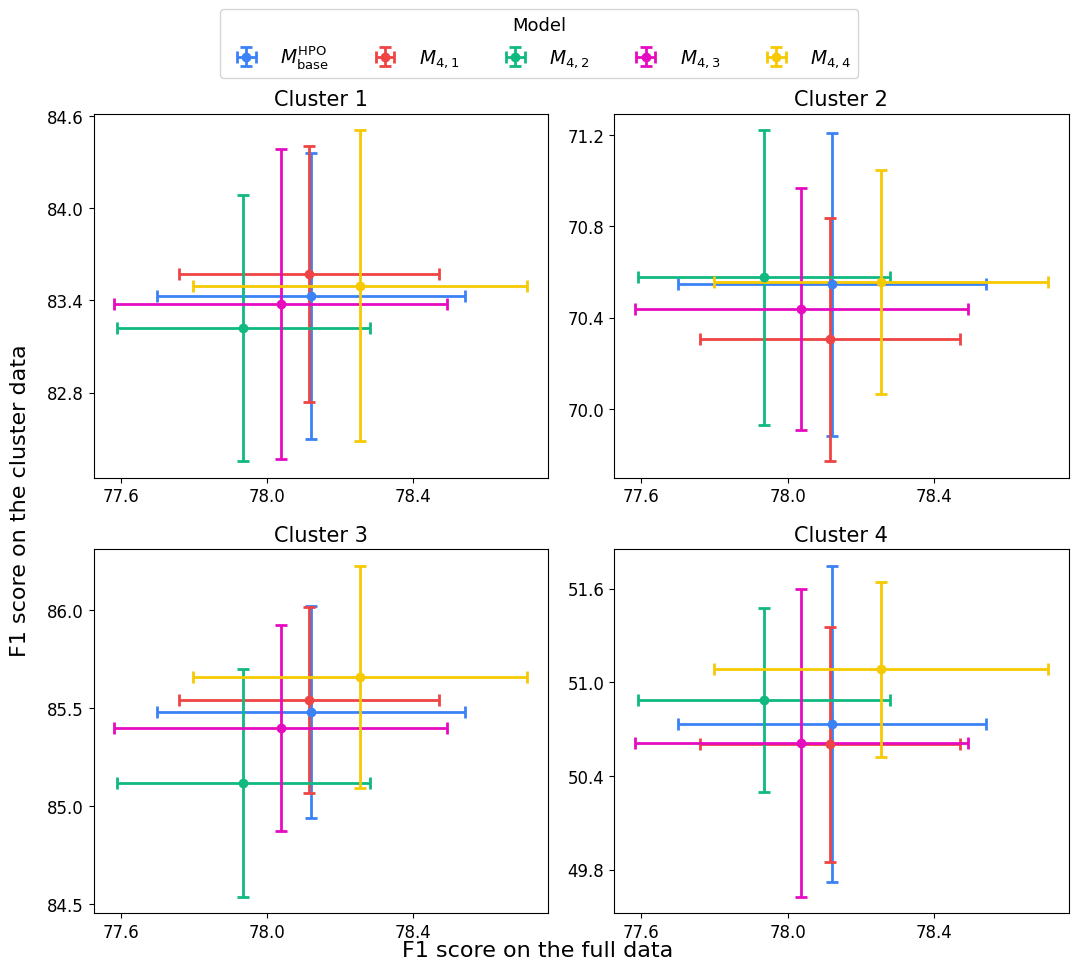

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

n_clusters = len(dataframes)
cluster_names = [f"Cluster {i+1}" for i  in range (n_clusters)]  
models = ["$M_{\\mathrm{base}}^{\\mathrm{HPO}}$"] + [
    f"$M_{{{n_clusters},{i+1}}}$" for i in range(n_clusters)
]
colors = ['#3b82f6', '#ef4444', '#10b981', "#e60bc1", "#f6c901"]


n_rows = (n_clusters + 1) // 2 
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 5 * n_rows))

axes = axes.flatten() if n_clusters > 1 else [axes]
fig.supxlabel("F1 score on the full data", fontsize=16, y=0.04)
fig.supylabel("F1 score on the cluster data", fontsize=16)
for idx, (df_total, cluster) in enumerate(zip(dataframes, cluster_names)):
    ax = axes[idx]
    
    full_scores_mean, full_scores_std, cluster_scores_mean, cluster_scores_std = get_scores_from_table(df_total)
    
    for i, model in enumerate(models):
        ax.errorbar(full_scores_mean[i], cluster_scores_mean[i], 
                    xerr=full_scores_std[i], yerr=cluster_scores_std[i],
                    fmt='o', capsize=4, capthick=2,markersize=6,
                    color=colors[i], label=model, linewidth=2) # 
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4)) 
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    print(metric)
    
    ax.set_title(f'{cluster}' )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(models),
    frameon=True,
    title = "Model"
    
)

if n_clusters % 2 != 0:
    axes[-1].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 2 clusters

In [ ]:
seeds = [0,1,2,3,4,5,6,7,8,9]
dataframes = []
json_path = "json_test_scores"
names =["baseline_hpo_trial_12_best","cluster_1_trial_47", "cluster_2_trial_69"] #"baseline_hpo_trial_12_best", "paper_baseline_99"
cluster_config =  "clusters2_layer6"
df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv"
metric = "F-measure_beat"
for cluster in [1,2]:
    df_total = get_all_metrics_cluster(seeds, json_path,names, cluster, cluster_config, df_path, metric )
    dataframes.append(df_total)

F-measure_beat
F-measure_beat


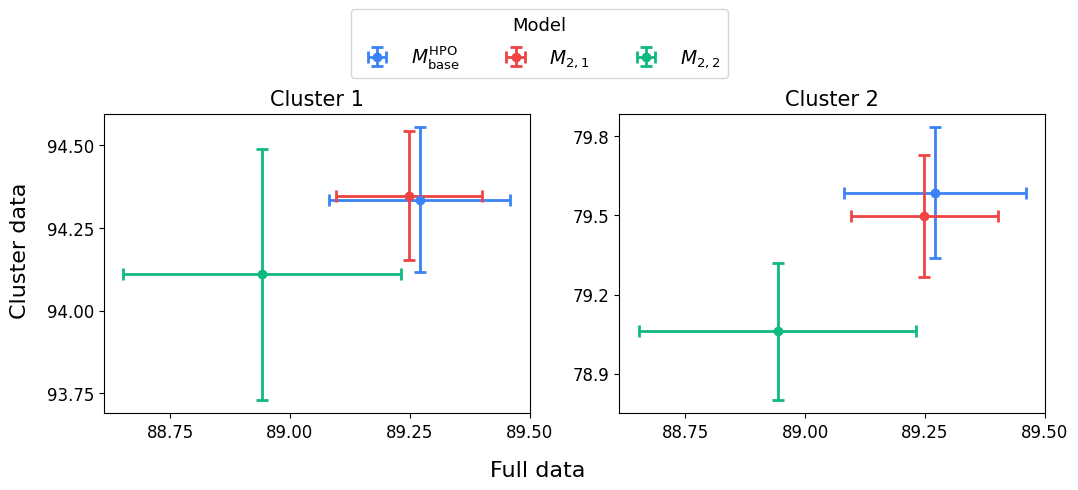

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

n_clusters = len(dataframes)
cluster_names = [f"Cluster {i+1}" for i  in range (n_clusters)]  
models = ["$M_{\\mathrm{base}}^{\\mathrm{HPO}}$"] + [
    f"$M_{{{n_clusters},{i+1}}}$" for i in range(n_clusters)
]
colors = ['#3b82f6', '#ef4444', '#10b981', "#e60bc1", "#f6c901"]

n_rows = (n_clusters + 1) // 2 
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 5 * n_rows))
axes = axes.flatten() if n_clusters > 1 else [axes]
fig.supxlabel("Full data", fontsize=16, y=0.04)
fig.supylabel("Cluster data", fontsize=16)
# Plot for each cluster
for idx, (df_total, cluster) in enumerate(zip(dataframes, cluster_names)):
    ax = axes[idx]
    full_scores_mean, full_scores_std, cluster_scores_mean, cluster_scores_std = get_scores_from_table(df_total)
    for i, model in enumerate(models):
        ax.errorbar(full_scores_mean[i], cluster_scores_mean[i], 
                    xerr=full_scores_std[i], yerr=cluster_scores_std[i],
                    fmt='o', capsize=4, capthick=2,markersize=6,
                    color=colors[i], label=model, linewidth=2) # 
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4)) 
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    print(metric)
    
    ax.set_title(f'{cluster}' )
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(models),
    frameon=True,
    title = "Model"
    
)
if n_clusters % 2 != 0:
    axes[-1].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.savefig("figures/2_cluster_errors_new.pdf")
plt.show()

## hypothesis testing


In [ ]:
def per_cluster_average(seeds, name, cluster, metric,  cluster_config,df_path, json_path= "json_test_scores", filter_files = True ):
    cluster_dataframes = []
    for seed in seeds:
        seed = [seed]
        cluster_model_cluster_results = get_restults_per_cluster (json_path,  cluster, seed, df_path, full= False,cluster_config = cluster_config, filter_files = filter_files, name = name, return_per_track = True, subfolder = "all_data_metrics"  )
        cluster_dataframes.append(cluster_model_cluster_results[[metric]])
    df_mean = pd.concat(cluster_dataframes).groupby(level=0).mean()
    indices = df_mean.index
    if "track" in indices[0]:
        df_mean.index = df_mean.index.str.replace("/track.npy", "", regex=False)
    return df_mean

In [ ]:
json_path = "json_test_scores"
df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
metric = "F-measure_beat"
seeds = [0,1,2,3,4,5,6,7,8,9]

df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
df_full= per_cluster_average(seeds = seeds, name = "paper_baseline_99", cluster= cluster, metric= metric,df_path= df_path, cluster_config= None)
df_full = df_full.sort_index()
df_full.mean()

In [ ]:
from scipy.stats import wilcoxon
json_path = "json_test_scores"
cluster, cluster_config = 4, "clusters4_layer12"
df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
metric = "AMLt_beat"
names =["baseline_hpo_trial_12_best", "cluster_1_trial_10", "cluster_2_trial_16", "cluster_3_trial_72", "cluster_4_trial_43"]
seeds = [0,1,2,3,4,5,6,7,8,9]
df_total = []
skip_cluster = [3]
for cluster in [1,2,3,4]:
    if cluster in skip_cluster:
        print(f"Skipping cluster {cluster}")
        df_cluster = df_full= per_cluster_average(seeds = seeds, name = names[0], cluster= cluster, metric= metric,df_path= df_path, cluster_config= None, filter_files = True)
    else:
        df_cluster = per_cluster_average(seeds = seeds, name = names[cluster], cluster= cluster, metric= metric, df_path= df_path, cluster_config= cluster_config, filter_files = True)
    df_total.append(df_cluster)
df_total = pd.concat (df_total, axis=0)
df_full= per_cluster_average(seeds = seeds, name = "paper_baseline_99", cluster= cluster, metric= metric,df_path= df_path, cluster_config= None, filter_files = False)
assert len(df_total) == 993
assert(len(df_full) == 993)
df_total = df_total.sort_index()
print(f"mean of clustered: {df_total.mean()}")
print(f"mean of df_full: {df_full.mean()}")
difference = df_total - df_full
print("Difference statistics (clustered - full data):")
print(difference.mean())
print(difference.std())
stat, p = wilcoxon(difference, alternative="greater")
print(f"Wilcoxon test statistic: {stat}, p-value: {p}")

using file   json_test_scores/all_data_metrics/clusters4_layer12/1/cluster_1_trial_10/epoch_best_seed_0_cluster_1_trial_10S_SEED_shift_tolerant_weighted_bce-h512-augTrueTrueTrue.json
number of files (238, 63)
using file   json_test_scores/all_data_metrics/clusters4_layer12/2/cluster_2_trial_16/epoch_best_seed_0_cluster_2_trial_16S_SEED_shift_tolerant_weighted_bce-h512-augTrueTrueTrue.json
number of files (217, 63)
Skipping cluster 3
using file   json_test_scores/all_data_metrics/baseline_hpo_trial_12_best/epoch_best_seed_0_full_model_trial12S_SEED_shift_tolerant_weighted_bce-h512-augTrueTrueTrue.json
number of files (435, 63)
using file   json_test_scores/all_data_metrics/clusters4_layer12/4/cluster_4_trial_43/epoch_best_seed_0_cluster_4_trial_43S_SEED_shift_tolerant_weighted_bce-h512-augTrueTrueTrue.json
number of files (103, 63)
using file   json_test_scores/all_data_metrics/paper_baseline_99/epoch_100_seed_0_periodic.json
number of files (993, 63)
mean of clustered: AMLt_beat    0.9